# Symbolic user functions

Notebook `python/Notebooks/tutorialSymbolic.ipynb`.

A nonlinear oscillator: a mass point on a Cartesian spring-damper whose force is a user function, written once in
Python and turned into a symbolic user function, which runs much faster. The outputs below each cell are those of the
last run.

In [1]:
import exudyn as exu
from exudyn.utilities import *  # includes itemInterface and rigidBodyUtilities
import exudyn.graphics as graphics

SC = exu.SystemContainer()
mbs = SC.AddSystem()
esym = exu.symbolic   #an abbreviation of the symbolic library; often it can be replaced by numpy

The parameters of the spring-damper system:

In [2]:
L = 0.5
mass = 1.6
k = 4000
omega0 = 50  # sqrt(k / mass)
dRel = 0.05
d = dRel * 2 * omega0
u0 = -0.08
v0 = 1
f = 80

The ground and the mass point with its initial conditions, the Cartesian spring-damper between them, a force on the
mass point, and a sensor of its position:

In [3]:
objectGround = mbs.CreateGround(referencePosition=[0, 0, 0])
massPoint = mbs.CreateMassPoint(referencePosition=[L, 0, 0],
                                initialDisplacement=[u0, 0, 0],
                                initialVelocity=[v0, 0, 0],
                                mass=mass)
csd = mbs.CreateCartesianSpringDamper(itemNumbers=[objectGround, massPoint],
                                      stiffness=[k, k, k],
                                      damping=[d, 0, 0],
                                      offset=[L, 0, 0])
load = mbs.CreateForce(itemNumber=massPoint, loadVector=[f, 0, 0])
sMass = mbs.AddSensor(SensorBody(bodyNumber=massPoint, storeInternal=True,
                                 outputVariableType=exu.OutputVariableType.Position))

The user function of the spring-damper, with Python or symbolic expressions - `esym.sign` works for both:

In [4]:
def springForceUserFunction(mbs, t, itemNumber, u, v, k, d, offset):
    return [0.5 * u[0]**2 * k[0] + esym.sign(v[0]) * 10, k[1] * u[1], k[2] * u[2]]

Up to here, this is a regular Python user function. `CreateSymbolicUserFunction` records it with symbolic arguments
and makes a symbolic user function, which is evaluated in C++; printing it shows the recorded expressions:

In [5]:
doSymbolic = True
CSDuserFunction = springForceUserFunction   #used if no symbolic user function is made
if doSymbolic:
    CSDuserFunction = CreateSymbolicUserFunction(mbs, springForceUserFunction, 'springForceUserFunction', csd)
    print('user function:\n', CSDuserFunction)

user function:
 [(((0.5 * pow(u[0], 2)) * k[0]) + (sign(v[0]) * 10)),(k[1] * u[1]),(k[2] * u[2])]


The user function goes to the object; then assemble and solve, with an explicit solver and small steps:

In [6]:
mbs.SetObjectParameter(csd, 'springForceUserFunction', CSDuserFunction)
mbs.Assemble()

simulationSettings = exu.SimulationSettings()
tEnd = 2
steps = 200000
simulationSettings.timeIntegration.numberOfSteps = steps
simulationSettings.timeIntegration.endTime = tEnd
simulationSettings.solution.file.write = False
simulationSettings.solution.sensors.writePeriod = 0.001

mbs.SolveDynamic(simulationSettings, solverType=exu.DynamicSolverType.ExplicitMidpoint)

n1 = mbs.GetObject(massPoint)['nodeNumber']
u = mbs.GetNodeOutput(n1, exu.OutputVariableType.Position)
print('u=', u)

u= [0.69752247 0.         0.        ]


The position of the mass point over time:

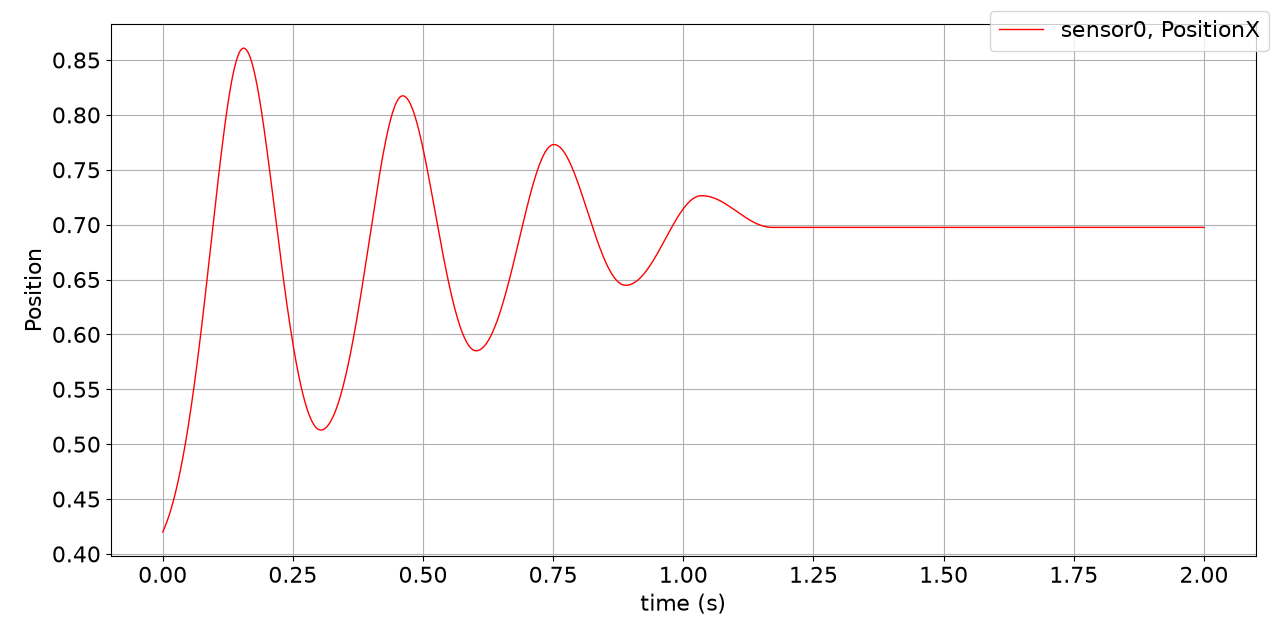

In [7]:
mbs.PlotSensor(sMass, components=[0], closeAll=True)